In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report, confusion_matrix

pd.options.display.float_format = '{:.4f}'.format
pd.set_option('display.max_colwidth', 200)

**Загрузка предсказаний**

In [5]:
bert_df = pd.read_parquet('parquets/bert_test_preds.parquet')
baseline_df = pd.read_parquet('parquets/svc_catboost_preds02.parquet')

# bert_pred id -> строка
child_encoder = LabelEncoder()
child_encoder.fit(bert_df['category_name'])
bert_df['bert_pred'] = child_encoder.inverse_transform(bert_df['bert_pred'])

# мерж по item_id
df = baseline_df[['item_id', 'text', 'parent_category_name', 'category_name', 
                  'tfidf_pred', 'catboost_pred']].merge(
    bert_df[['item_id', 'bert_pred']], on='item_id'
)

print('Размер:', df.shape)
df.head(2)

Размер: (30000, 7)


,item_id,text,parent_category_name,category_name,tfidf_pred,catboost_pred,bert_pred
0,9ecc831dcd04,"Домашняя копченая грудинка, колбаса, сало!. Продажа опт и розница домашней мясной продукции! Кровяная колбаса, копченая грудинка, мясо карбонат, сало соленое, колбаса мясная с чесноком, копченые к...",Для дома и дачи,Продукты питания,Продукты питания,Продукты питания,Продукты питания
1,2cdcd8a35e22,"Супер собака. стерилизованная девочка 10 мес, отлично сторожит и отличный характер.",Животные,Собаки,Собаки,Кошки,Собаки


---

**Сводная таблица метрик**

In [6]:
models = {
    'Level 0: TF-IDF': 'tfidf_pred',
    'Level 1: CatBoost': 'catboost_pred',
    'Level 2: BERT': 'bert_pred',
}

results = []
for name, col in models.items():
    results.append({
        'Model': name,
        'F1-macro': f1_score(df['category_name'], df[col], average='macro', zero_division=0),
        'F1-weighted': f1_score(df['category_name'], df[col], average='weighted', zero_division=0),
    })

pd.DataFrame(results)

,Model,F1-macro,F1-weighted
0,Level 0: TF-IDF,0.8463,0.8944
1,Level 1: CatBoost,0.8384,0.9472
2,Level 2: BERT,0.8477,0.8747


---

**Per-class F1 для BERT**

In [7]:
report = classification_report(df['category_name'], df['bert_pred'], 
                               output_dict=True, zero_division=0)

per_class_df = pd.DataFrame(report).T.iloc[:-3].sort_values('f1-score')

print('Худшие 10:')
print(per_class_df.head(10)[['precision', 'recall', 'f1-score', 'support']])

print('\nЛучшие 10:')
print(per_class_df.tail(10)[['precision', 'recall', 'f1-score', 'support']])

Худшие 10:
                           precision  recall  f1-score  support
Охота и рыбалка               0.4626  0.7556    0.5738  90.0000
Оборудование для бизнеса      0.5499  0.6375    0.5904 320.0000
Коллекционирование            0.6255  0.6667    0.6454 486.0000
Продукты питания              0.6122  0.7759    0.6844 116.0000
Спорт и отдых                 0.6271  0.8189    0.7103 497.0000
Посуда и товары для кухни     0.6175  0.8564    0.7176 181.0000
Готовый бизнес                0.6102  0.8780    0.7200  41.0000
Музыкальные инструменты       0.6413  0.8872    0.7445 133.0000
Велосипеды                    0.6863  0.8774    0.7702 212.0000
Оргтехника и расходники       0.7315  0.8258    0.7758 132.0000

Лучшие 10:
                           precision  recall  f1-score   support
Ноутбуки                      0.9387  0.9660    0.9522  206.0000
Телефоны                      0.9731  0.9339    0.9531 1316.0000
Коммерческая недвижимость     0.9573  0.9515    0.9544  165.0000
Гаражи и маши

---

**Ошибки внутри parent vs между parent**

In [8]:
child_to_parent = df.groupby('category_name')['parent_category_name'].first().to_dict()

for name, col in models.items():
    pred_parents = df[col].map(child_to_parent)
    correct = df[col] == df['category_name']
    same_parent = pred_parents == df['parent_category_name']
    
    total = (~correct).sum()
    inside = ((~correct) & same_parent).sum()
    between = ((~correct) & ~same_parent).sum()
    
    print(f'\n{name}')
    print(f'Всего ошибок: {total} ({total/len(df)*100:.1f}%)')
    print(f'  внутри parent: {inside} ({inside/total*100:.1f}%)')
    print(f'  между parent: {between} ({between/total*100:.1f}%)')


Level 0: TF-IDF
Всего ошибок: 3179 (10.6%)
  внутри parent: 1498 (47.1%)
  между parent: 1681 (52.9%)

Level 1: CatBoost
Всего ошибок: 1686 (5.6%)
  внутри parent: 462 (27.4%)
  между parent: 1224 (72.6%)

Level 2: BERT
Всего ошибок: 3810 (12.7%)
  внутри parent: 1852 (48.6%)
  между parent: 1958 (51.4%)


---

**Топ путаемых пар у BERT**

In [ ]:
errors = df[df['category_name'] != df['bert_pred']]
pairs = (errors.groupby(['category_name', 'bert_pred']).size().reset_index(name='count').sort_values('count', ascending=False).head(15))

for _, row in pairs.iterrows():
    same = child_to_parent.get(row['category_name']) == child_to_parent.get(row['bert_pred'])
    parent = 'один родитель' if same else 'разные'
    print(f"{row['count']:>4}  {row['category_name']} -> {row['bert_pred']}  ({parent})")

 596  Детская одежда и обувь -> Одежда, обувь, аксессуары  (один родитель)
 475  Одежда, обувь, аксессуары -> Детская одежда и обувь  (один родитель)
  79  Ремонт и строительство -> Оборудование для бизнеса  (разные)
  77  Одежда, обувь, аксессуары -> Спорт и отдых  (разные)
  77  Товары для детей и игрушки -> Мебель и интерьер  (разные)
  69  Товары для детей и игрушки -> Велосипеды  (разные)
  65  Мебель и интерьер -> Коллекционирование  (разные)
  56  Товары для детей и игрушки -> Спорт и отдых  (разные)
  53  Одежда, обувь, аксессуары -> Красота и здоровье  (один родитель)
  47  Детская одежда и обувь -> Спорт и отдых  (разные)
  37  Одежда, обувь, аксессуары -> Коллекционирование  (разные)
  37  Мебель и интерьер -> Товары для детей и игрушки  (разные)
  36  Оборудование для бизнеса -> Ремонт и строительство  (разные)
  34  Детская одежда и обувь -> Товары для детей и игрушки  (один родитель)
  33  Предложение услуг -> Ремонт и строительство  (разные)


---

**Confusion matrix BERT на parent-уровне**

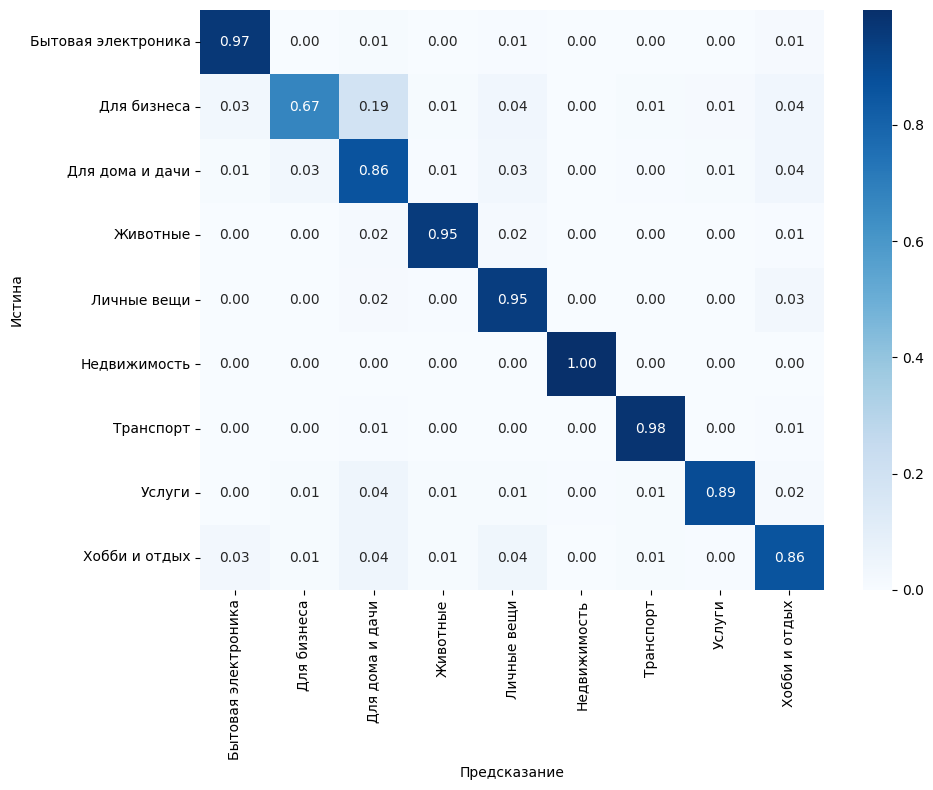

In [ ]:
df['bert_pred_parent'] = df['bert_pred'].map(child_to_parent)

parents = sorted(df['parent_category_name'].unique())
cm = confusion_matrix(df['parent_category_name'], df['bert_pred_parent'], 
                      labels=parents, normalize='true') # числа / сумма строки - для удобной интерпретации = сумма строки 1.0 

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=parents, yticklabels=parents)
plt.xlabel('Предсказание')
plt.ylabel('Истина')
plt.tight_layout()
plt.show()

---

**Примеры ошибок BERT**

In [14]:
sample = df[df['category_name'] != df['bert_pred']].sample(8, random_state=1337)

for _, row in sample.iterrows():
    same = child_to_parent.get(row['category_name']) == child_to_parent.get(row['bert_pred'])
    parent = 'один родитель' if same else 'разные родители'
    print(f'[{parent}]')
    print(f'Истина: {row["category_name"]}')
    print(f'Предсказание: {row["bert_pred"]}')
    print(f'Текст: {row["text"][:200]}')
    print()

[один родитель]
Истина: Детская одежда и обувь
Предсказание: Одежда, обувь, аксессуары
Текст: Туфли. Обувь не ношеная в отличном состоянии

[один родитель]
Истина: Одежда, обувь, аксессуары
Предсказание: Детская одежда и обувь
Текст: Утепленные ботинки. Ботинки в отличном состоянии

[разные родители]
Истина: Товары для детей и игрушки
Предсказание: Спорт и отдых
Текст: Бассейн каркасный. В хорошем состоянии 3.05м75 гл

[один родитель]
Истина: Одежда, обувь, аксессуары
Предсказание: Детская одежда и обувь
Текст: Кофта-толстовка. Толстовка в отличном состоянии.Цвет: черный.

[разные родители]
Истина: Мебель и интерьер
Предсказание: Оборудование для бизнеса
Текст: Продам Ножка круглая 710х60 мм цвет бронза. Продам Ножки круглые 710х60 мм цвет бронза, 3 шт., в отличном состоянии.

[один родитель]
Истина: Собаки
Предсказание: Птицы
Текст: Маломут. Кабель 1, 5 года. Добрый. Продаем в связи с тем что нет возможности содержать. Прививки есть.

[разные родители]
Истина: Товары для детей и игруш

---

**Вывод**

- По F1-macro лучший BERT (0.8477), затем TF-IDF (0.8463), затем CatBoost (0.8384)
- По F1-weighted лучший CatBoost (0.9472) - вырывается на крупных классах за счёт табличных фич
- CatBoost ошибается меньше всех (5.6% против 10-13% у text-моделей)
- Худшие классы у BERT: Охота и рыбалка, Оборудование для бизнеса 
- Идеально классифицируются Автомобили, Квартиры, Гаражи 
- Самая частая ошибка: Одежда <-> Детская одежда (~1000 случаев) - перекрытие категорий
- У TF-IDF и BERT ошибки поровну между внутри/между parent. CatBoost ошибается меньше, но 73% его ошибок - между parent